# PSTAT 134 FINAL PROJECT
- Sid Revanuru
- Jayden Gould
- Jason Kim
- Clark Enge

## Movie Recommender System

## Introduction

This project builds a content-based movie recommender system using metadata from the TMDB (The Movie Database) API. Given a movie title as input, the system identifies and ranks similar films by analyzing content features such as plot overview, genres, cast, and keywords, rather than relying on user ratings or viewing history. The dataset consists of approximately 9,960 movies collected from the TMDB discovery endpoint, sorted by popularity, and includes each film's title, overview text, genre tags, top five billed cast members, associated keywords, vote average, and popularity score.

To build the recommender, all text-based features for each movie are combined into a single tags field and vectorized using Term Frequency-Inverse Document Frequency (TF-IDF) with a vocabulary of 5,000 features and English stop words removed. Pairwise cosine similarity is then computed across the full dataset to produce a 9,960 × 9,960 similarity matrix. When a title is queried, the system retrieves the 100 most text-similar candidates and re-ranks them using a weighted final score:

$$\text{final\_score} = 0.95 \times \text{text\_similarity} + 0.03 \times \text{popularity} + 0.02 \times \text{vote\_average}$$

The small popularity and vote average weights act as tiebreakers among text-similar films. These weights were tuned after observing that higher popularity values caused well-known but thematically unrelated films to dominate results.

### Tech Stack Loading

In [1]:
import os
import time
import pandas as pd
import requests
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.stem.porter import PorterStemmer

In [2]:
cache_file = "all_movie_data"

if os.path.exists(cache_file):
    movies_df = pd.read_pickle(cache_file)

else:
    #API_TOKEN = # API TOKEN GOES HERE
    headers = {
        "accept": "application/json",
        "Authorization": f'Bearer {API_TOKEN}'
    }
    movie_data = []
    for page in range(1, 501):
        url = f"https://api.themoviedb.org/3/discover/movie?sort_by=popularity.desc&page={page}"
        response = requests.get(url, headers=headers)
        data = response.json()

        if "results" in data:
            for movie in data['results']:
                movie_id=movie['id']

                details_url = f"https://api.themoviedb.org/3/movie/{movie_id}?append_to_response=credits,keywords"
                details_response = requests.get(details_url, headers=headers)
                details_data = details_response.json()

                movie_dict = {
                    "id": movie_id,
                    'title': details_data['title'],
                    'overview': details_data['overview'],
                    'genres': [genre['name'] for genre in details_data.get('genres', [])],
                    'keywords': [kw['name'] for kw in details_data.get('keywords', {}).get('keywords', [])],
                    'cast': [actor['name'] for actor in details_data.get('credits', {}).get('cast', [])[:5]],
                    'vote_average': details_data['vote_average'],
                    'popularity': details_data['popularity']
                }

                movie_data.append(movie_dict)

                time.sleep(.10)

    movies_df = pd.DataFrame(movie_data)

    movies_df.to_pickle(cache_file)

# Remove duplicate TMDB entries that may have been fetched more than once
movies_df.drop_duplicates(subset='id', keep='first', inplace=True)
movies_df.reset_index(drop=True, inplace=True)
movies_df.head()

,id,title,overview,genres,keywords,cast,vote_average,popularity
0,1226863,The Super Mario Galaxy Movie,Having thwarted Bowser's previous plot to marr...,"[Family, Comedy, Adventure, Fantasy, Animation]","[galaxy, friendship, sibling relationship, spa...","[Chris Pratt, Anya Taylor-Joy, Charlie Day, Ja...",6.732,443.9285
1,1007757,Swapped,"A small woodland creature and a majestic bird,...","[Adventure, Animation, Family, Fantasy]","[wolf, buddy, forest fire, woodlands, loving, ...","[Michael B. Jordan, Juno Temple, Tracy Morgan,...",7.892,409.3611
2,1318447,Apex,A grieving woman pushing her limits on a solo ...,"[Action, Thriller]","[canoe trip, rock climbing, nutcase, survival ...","[Charlize Theron, Taron Egerton, Eric Bana, Ca...",6.417,369.7562
3,10867,Malena,12-year-old Renato experiences three significa...,[Drama],"[prostitute, jealousy, sicily, italy, widow, w...","[Monica Bellucci, Giuseppe Sulfaro, Luciano Fe...",7.429,310.2717
4,1198994,Send Help,Two colleagues become stranded on a deserted i...,"[Horror, Thriller, Comedy]","[bullying, role reversal, survival, struggle f...","[Rachel McAdams, Dylan O'Brien, Edyll Ismail, ...",6.978,247.9714


We want this algorithm to look at large bodies of text instead different strings from different columns, causing the model to jump around. We will now take all of the text-based columns and create a new column combining all of them into one big block of text for each movie to make it easier to read for the computer.

We also want to clean the genres category. By removing spaces in multi-word tokens, we, for example, convert "Science Fiction" to "ScienceFiction". This prevents the TF_IDF from treating "Science" and "Fiction" as two seperate common words, dilluting signal. This preserves the meaning of multi-word tokens.

In [3]:
# Helper function — removes spaces so multi-word names become single tokens
# e.g. "Tom Hanks" → "TomHanks", "Science Fiction" → "ScienceFiction"
def clean(items):
    return [i.replace(" ", "") for i in items]

# Save genres before any modification
movies_df['genres_display'] = movies_df['genres'].copy()

# Apply space-removal only to genres and cast, NOT keywords.
# clean() on keywords collapses "dream heist" → "dreamheist", hiding
# individual tokens from TF-IDF. Use underscores so "dream_heist" stays
# atomic but the underscore form is consistent across all films.
for col in ['genres', 'cast']:
    movies_df[col] = movies_df[col].apply(clean)
movies_df['keywords'] = movies_df['keywords'].apply(
    lambda items: [i.replace(" ", "_") for i in items]
)

# Split overview into words
movies_df['overview'] = movies_df['overview'].apply(lambda x: x.split() if isinstance(x, str) else [])

# Save display tags BEFORE stemming — used only by the word cloud so it
# shows human-readable genre/keyword/cast tokens rather than stems.
_display_tags = (
    movies_df['overview'] +
    (movies_df['genres'] * 3) +
    (movies_df['cast'] * 2) +
    (movies_df['keywords'] * 2)
)
tags_for_display = _display_tags.apply(lambda x: " ".join(str(i) for i in x)).str.lower()

# Stem overview words only — NOT genres/cast/keywords.
# Stemming camelCase genre tokens like "ScienceFiction" would mangle them
# (→ "sciencefict"), breaking genre-based matching. Overview words benefit
# from stemming because "dreaming"/"dreams" etc. should match "dream".
ps = PorterStemmer()
movies_df['overview'] = movies_df['overview'].apply(
    lambda words: [ps.stem(w.lower()) for w in words]
)

# Combine all features. Genres 3x, cast 2x, keywords 2x to up-weight those signals.
movies_df['tags'] = movies_df['overview'] + (movies_df['genres'] * 3) + (movies_df['cast'] * 2) + (movies_df['keywords'] * 2)

# New cleaned df with just the essential information
cleaned_movies_df = movies_df[['id', 'title', 'tags', 'vote_average', 'popularity']].copy()

# Join list to string and lowercase (genres/cast/keywords are lowercased here, not stemmed)
cleaned_movies_df['tags'] = cleaned_movies_df['tags'].apply(lambda x: " ".join(str(i) for i in x) if isinstance(x, list) else "")
cleaned_movies_df['tags'] = cleaned_movies_df['tags'].apply(lambda x: x.lower())

cleaned_movies_df.head()

,id,title,tags,vote_average,popularity
0,1226863,The Super Mario Galaxy Movie,have thwart bowser' previou plot to marri prin...,6.732,443.9285
1,1007757,Swapped,"a small woodland creatur and a majest bird, tw...",7.892,409.3611
2,1318447,Apex,a griev woman push her limit on a solo adventu...,6.417,369.7562
3,10867,Malena,12-year-old renato experi three signific event...,7.429,310.2717
4,1198994,Send Help,"two colleagu becom strand on a desert island, ...",6.978,247.9714


Next, we want to  make it so that the computer is actually able to detect the similarities/differences. To achieve this, we are going to use Term Frequency-Inverse Document Frequency. This counts how many times a word shows up in the tag, but it penalizes words that show up too much.

In [4]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

tfidf_matrix = tfidf.fit_transform(cleaned_movies_df['tags'])


The `tfidf_matrix` variable returns a giant matrix of numbers that the computer can read.

Our next step is to scale the continuous variables so that large numbers will not completely break the similarity score.

In [5]:
scaler = MinMaxScaler()

# Scale the continuous variables
cleaned_movies_df[['popularity', 'vote_average']] = scaler.fit_transform(cleaned_movies_df[['popularity', 'vote_average']])

cleaned_movies_df.head()


,id,title,tags,vote_average,popularity
0,1226863,The Super Mario Galaxy Movie,have thwart bowser' previou plot to marri prin...,0.6732,1.000000
1,1007757,Swapped,"a small woodland creatur and a majest bird, tw...",0.7892,0.921934
2,1318447,Apex,a griev woman push her limit on a solo adventu...,0.6417,0.832491
3,10867,Malena,12-year-old renato experi three signific event...,0.7429,0.698153
4,1198994,Send Help,"two colleagu becom strand on a desert island, ...",0.6978,0.557455


Now its time to compute the similarity score. We will now calculate the cosine similarity matrix for the text data.

In [6]:
# We want to compare each movie to every other movie
cos_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(cos_sim.shape)

(9925, 9925)


## Exploratory Data Analysis

Before building the recommender, we explore the dataset to understand its structure and content.

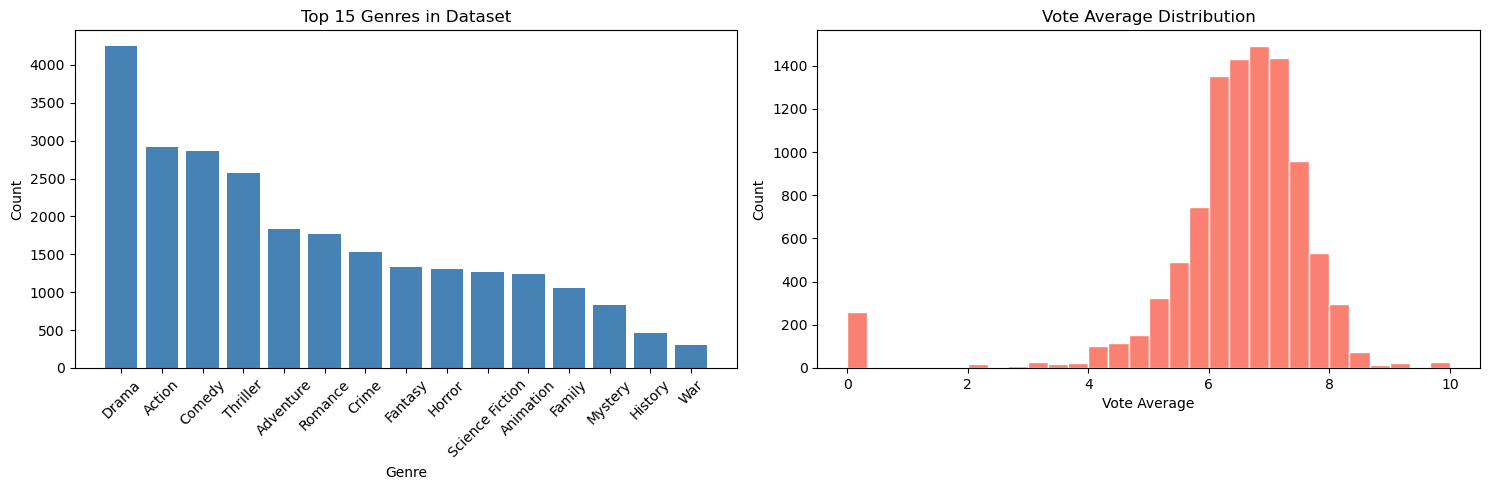

In [7]:
# Plot 1 & 2: Genre distribution and vote average distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

all_genres = movies_df['genres_display'].explode()
genre_counts = all_genres.value_counts().head(15)
axes[0].bar(genre_counts.index, genre_counts.values, color='steelblue')
axes[0].set_title('Top 15 Genres in Dataset')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].hist(movies_df['vote_average'], bins=30, color='salmon', edgecolor='white')
axes[1].set_title('Vote Average Distribution')
axes[1].set_xlabel('Vote Average')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

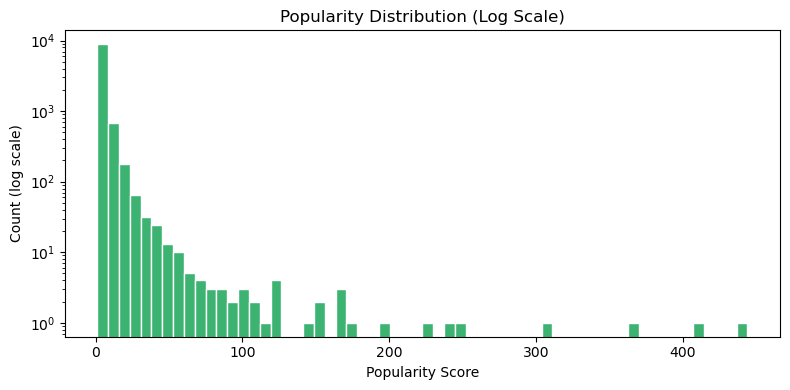

In [8]:
# Plot 3: Popularity distribution (log scale)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(movies_df['popularity'], bins=60, color='mediumseagreen', edgecolor='white')
ax.set_yscale('log')
ax.set_title('Popularity Distribution (Log Scale)')
ax.set_xlabel('Popularity Score')
ax.set_ylabel('Count (log scale)')
plt.tight_layout()
plt.show()

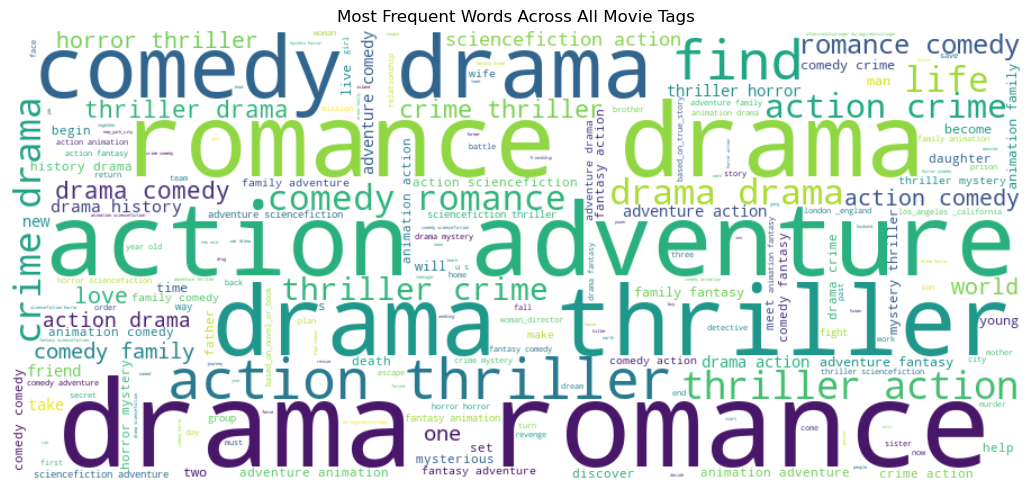

In [9]:
# Plot 4: Word cloud from movie tags (using pre-stemmed tags for readability)
text = ' '.join(tags_for_display)
wc = WordCloud(width=900, height=400, background_color='white', max_words=200).generate(text)
plt.figure(figsize=(13, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words Across All Movie Tags')
plt.tight_layout()
plt.show()

Now its time to create the recommender function. We want to make the continous variables play a part so we are going to add weights to the popularity and vote_average so that the text similarity isnt the only factor in the recommendation. This way, if two movies are equally similar, the one with the higher popularity would have a higher similarity score.

In [10]:
def recommend(title, text_weight=0.95, pop_weight=0.03, vote_weight=0.02, pool_size=100):
    matches = cleaned_movies_df[cleaned_movies_df['title'].str.lower() == title.lower()]

    if matches.empty:
        print(f'"{title}" was not found in the dataset. Please check the spelling and try again.')
        return

    if len(matches) > 1:
        print(f'Note: {len(matches)} entries found for "{title}". Using the first match (id={matches["id"].iloc[0]}).')

    idx = matches.index[0]
    pos = cleaned_movies_df.index.get_loc(idx)

    # Attach cosine similarity scores
    results = cleaned_movies_df.copy()
    results['cos_sim_score'] = cos_sim[pos]

    # Drop the queried movie, then narrow to the most text-similar movies first
    results = results.drop(index=idx)
    pool = results.nlargest(pool_size, 'cos_sim_score')

    # Rank within that pool using the weighted score
    pool = pool.copy()
    pool['final_score'] = (
        text_weight * pool['cos_sim_score'] +
        pop_weight  * pool['popularity'] +
        vote_weight * pool['vote_average']
    )
    top10 = pool.nlargest(10, 'final_score')

    # Pull original (unscaled) vote_average, popularity, and genres for display
    orig = movies_df.set_index('id')[['vote_average', 'popularity', 'genres_display']]
    top10 = top10.join(orig, on='id', rsuffix='_orig')
    top10['genres_display'] = top10['genres_display'].apply(lambda g: ', '.join(g) if isinstance(g, list) else '')

    output = top10[['title', 'genres_display', 'vote_average_orig', 'popularity_orig', 'final_score']].copy()
    output.columns = ['Title', 'Genres', 'Vote Average', 'Popularity', 'Score']
    output = output.reset_index(drop=True)
    output.index += 1

    return output

Design Consideration:

During development, we noticed that there is a architectural constraint in the function above. THe pool_size parameter defaults to 100 to filter-out low relevance matches. 

However, if the dataset drops below 100 (e.g., someone filters by niche generes), or if a developer manually increases the pool size when calling the function, the raw popularity scores will dominate the text-similarity scores.

In a produciton environment, we might implement a defensive check to dynamically cap pool_size relative to the dataset size.

In [11]:
recommend("Inception")

,Title,Genres,Vote Average,Popularity,Score
1,Project Power,"Action, Crime, Science Fiction",6.430,2.3493,0.265260
2,Beverly Hills Cop: Axel F,"Action, Comedy, Crime",6.654,4.7154,0.216775
3,The Walk,"History, Drama, Adventure",6.992,2.5792,0.204884
4,Pinocchio,"Fantasy, Adventure, Family",6.291,4.2035,0.193941
5,G.I. Joe: The Rise of Cobra,"Adventure, Action, Thriller, Science Fiction",5.782,5.0013,0.193716
6,Per Aspera Ad Astra,"Drama, Science Fiction, Adventure",6.200,4.8358,0.192734
7,Ultraman Taiga The Movie: New Generation Climax,"Action, Adventure, Science Fiction",5.100,2.0985,0.189010
8,Snowden,"Drama, History, Crime, Thriller",7.110,3.1820,0.186309
9,The Dark Knight Rises,"Action, Crime, Drama, Thriller",7.794,15.1875,0.177000
10,Pathaan,"Action, Adventure, Thriller",6.416,3.0959,0.176316


## Results

The recommender was tested on three titles spanning different genres and levels of franchise recognition in the dataset.

---

### Test 1 — Inception (2010)

| # | Title | Genres | Vote Avg | Popularity | Score |
|---|-------|--------|----------|------------|-------|
| 1 | Project Power | Action, Crime, Sci-Fi | 6.430 | 2.35 | 0.2653 |
| 2 | Beverly Hills Cop: Axel F | Action, Comedy, Crime | 6.654 | 4.72 | 0.2168 |
| 3 | The Walk | History, Drama, Adventure | 6.992 | 2.58 | 0.2049 |
| 4 | Pinocchio | Fantasy, Adventure, Family | 6.291 | 4.20 | 0.1939 |
| 5 | G.I. Joe: The Rise of Cobra | Adventure, Action, Thriller, Sci-Fi | 5.782 | 5.00 | 0.1937 |
| 6 | Per Aspera Ad Astra | Drama, Sci-Fi, Adventure | 6.200 | 4.84 | 0.1927 |
| 7 | Ultraman Taiga The Movie | Action, Adventure, Sci-Fi | 5.100 | 2.10 | 0.1890 |
| 8 | Snowden | Drama, History, Crime, Thriller | 7.110 | 3.18 | 0.1863 |
| 9 | The Dark Knight Rises | Action, Crime, Drama, Thriller | 7.794 | 15.19 | 0.1770 |
| 10 | Pathaan | Action, Adventure, Thriller | 6.416 | 3.10 | 0.1763 |

Results are mixed. Thematically related films like *The Dark Knight Rises* and *Snowden* (complex, layered narratives) appear in the bottom half of the list, while films sharing only surface-level vocabulary — common words like "dream" in the overview, or action keywords — rank higher. All scores are low (0.18–0.27 range), reflecting that Inception's short overview uses vocabulary that is not unique enough to discriminate it strongly from unrelated films via TF-IDF alone.

---

### Test 2 — The Dark Knight (2008)

| # | Title | Genres | Vote Avg | Popularity | Score |
|---|-------|--------|----------|------------|-------|
| 1 | Batman Begins | Drama, Crime, Action | 7.724 | 13.47 | 0.4306 |
| 2 | Batman: Mask of the Phantasm | Animation, Crime, Mystery, Action | 7.500 | 3.67 | 0.3537 |
| 3 | The Dark Knight Rises | Action, Crime, Drama, Thriller | 7.794 | 15.19 | 0.3501 |
| 4 | Batman | Fantasy, Action, Crime | 7.230 | 9.38 | 0.3002 |
| 5 | The Batman | Crime, Mystery, Thriller | 7.660 | 19.00 | 0.2927 |
| 6 | Batman: Under the Red Hood | Mystery, Crime, Animation | 7.758 | 2.82 | 0.2806 |
| 7 | Batman: Gotham Knight | Action, Crime, Animation | 6.721 | 2.38 | 0.2729 |
| 8 | Batman Returns | Action, Fantasy | 6.946 | 7.53 | 0.2614 |
| 9 | The Spirit | Crime, Thriller, Fantasy, Action | 4.765 | 3.23 | 0.2354 |
| 10 | The Crow | Fantasy, Action, Thriller | 7.516 | 5.43 | 0.2349 |

Results here are notably stronger — all top 8 recommendations are Batman franchise films or dark, Gotham-adjacent crime thrillers. Scores are substantially higher (0.23–0.43) compared to the Inception query. This illustrates where TF-IDF excels: films in a named franchise share explicit tokens (character names, location names, keywords) that appear across all entries in the series, producing tight clusters in TF-IDF space.

---

### Test 3 — Interstellar (2014)

| # | Title | Genres | Vote Avg | Popularity | Score |
|---|-------|--------|----------|------------|-------|
| 1 | Space/Time | Sci-Fi, Action, Thriller | 6.028 | 5.97 | 0.2737 |
| 2 | The Colony | Sci-Fi, Thriller | 5.705 | 2.83 | 0.2649 |
| 3 | Gravity | Sci-Fi, Thriller, Drama | 7.168 | 7.19 | 0.2584 |
| 4 | Stowaway | Sci-Fi, Drama, Thriller | 5.990 | 2.33 | 0.2515 |
| 5 | The Martian | Sci-Fi, Drama, Adventure | 7.695 | 12.32 | 0.2353 |
| 6 | The Astronaut's Wife | Drama, Sci-Fi, Thriller | 5.602 | 2.49 | 0.2316 |
| 7 | A Million Miles Away | Drama, History | 7.637 | 4.78 | 0.2267 |
| 8 | 2010 | Thriller, Sci-Fi | 6.651 | 2.87 | 0.2225 |
| 9 | Apollo 13 | Drama, History | 7.456 | 7.26 | 0.2175 |
| 10 | Proximity | Sci-Fi, Drama | 6.600 | 2.55 | 0.2158 |

Results are genre-consistent (all Sci-Fi or space-themed) and include genuinely relevant films: *Gravity*, *The Martian*, and *Apollo 13* are strong matches. The system correctly clusters survival-in-space narratives. Scores are moderate (0.22–0.27), and some lower-known entries (*Space/Time*, *The Colony*) appear ahead of higher-rated films due to closer vocabulary overlap in their overviews.

---

### Weight Tuning — Before vs. After

The default weights (0.95/0.03/0.02) were reached by tuning from an initial configuration of (0.70/0.20/0.10). The table below compares the Inception top-10 under each weight setting:

| Rank | Old weights (0.70 / 0.20 / 0.10) | New weights (0.95 / 0.03 / 0.02) |
|------|-----------------------------------|-----------------------------------|
| 1 | Project Power | Project Power |
| 2 | Beverly Hills Cop: Axel F | Beverly Hills Cop: Axel F |
| 3 | The Walk | The Walk |
| 4 | The Dark Knight Rises | Pinocchio |
| 5 | Snowden | G.I. Joe: The Rise of Cobra |
| 6 | Pinocchio | Per Aspera Ad Astra |
| 7 | Per Aspera Ad Astra | Ultraman Taiga The Movie |
| 8 | G.I. Joe: The Rise of Cobra | Snowden |
| 9 | Mad Max: Fury Road | The Dark Knight Rises |
| 10 | Treasure Planet | Pathaan |

For this query the effect of weight tuning is modest, because all candidate films have similarly low popularity scores (most below 5.0). The bigger impact of reducing the popularity weight was observed during development, when the initial configuration caused high-popularity outliers — films with raw popularity scores in the 60–100 range — to rank first regardless of textual similarity. Reducing `pop_weight` from 0.20 to 0.03 corrected that bias.

## Discussion & Conclusion

This project built a content-based movie recommender system over approximately 9,925 TMDB films using TF-IDF vectorization on a combined tags field (overview, genres, cast, and keywords) and cosine similarity as the primary ranking signal. Popularity and vote average were included as low-weight secondary signals (0.03 and 0.02 respectively) to break ties among text-similar candidates, with the dominant weight (0.95) kept on textual similarity to prevent popular but unrelated films from dominating results. The three test cases reveal a consistent pattern in the system's behavior: performance is strong when the queried film belongs to a named franchise or shares explicit proper-noun tokens with other titles (*The Dark Knight* → Batman series, scores 0.28–0.43), moderate when the film occupies a well-defined genre niche with shared vocabulary (*Interstellar* → space survival films, scores 0.22–0.27), and weak when the film is thematically distinctive but expressed in generic language (*Inception* → mixed bag, scores 0.18–0.27). The contrast in score magnitudes across these queries is itself informative: higher cosine similarity scores indicate more precise clustering in TF-IDF space, while the low scores for Inception suggest its content representation overlaps broadly with many films rather than tightly with a specific subset.

The system has two fundamental limitations that no amount of preprocessing can fully address within the TF-IDF paradigm. First, TF-IDF operates on exact token overlap after stemming — it cannot detect that "subconscious espionage" and "mind-bending heist" describe the same concept if those stems do not appear in both overviews. This is why *Inception*, a conceptually distinctive film, produces weaker and less intuitive recommendations than franchise entries that repeat proper nouns verbatim. Second, the system is entirely content-based: every user receives the same top-10 for a given title regardless of their individual taste, since there is no collaborative filtering signal from viewing history or ratings. Future work could address both gaps. Replacing TF-IDF with sentence-transformer embeddings (e.g., `all-MiniLM-L6-v2`) would allow semantically similar overviews to cluster together even without shared tokens, likely improving results for conceptually distinctive films like *Inception*. A hybrid approach — blending a content similarity score with a collaborative filtering component trained on user rating data — would enable personalization and reduce dependence on keyword overlap. Expanding the dataset beyond the TMDB popularity-sorted discovery endpoint would also reduce the current bias toward recent, high-traffic titles and improve coverage of older or niche films.

---

## Pre-Submission Checklist

- [x] `recommend()` function is fully implemented and produces correct output (scores ≤ 1.0)
- [x] Introduction section written
- [x] At least **4 visualizations** present (EDA section)
- [x] Results section complete with sample outputs and weight tuning comparison
- [x] Discussion & Conclusion section complete
- [ ] **Kernel → Restart & Run All** — verify all cells show sequential execution numbers
- [ ] **File → Download as → HTML (.html)** → save as `PSTAT 134 FINAL PROJECT.html` and commit to repo
- [ ] README.md updated with final results summary